### 4. Undercomplete Autoencoders:
- Undercomplete Autoencoders intentionally restrict size of the hidden layer to be smaller than the input layer.
- This bottleneck forces the model to compress the data helps in learning only the most significant features and discarding the redundant information.
- The model is trained by minimizing the reconstruction error while ensuring the latent space remains compact.

### Implementation of Undercomplete Autoencoders:

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4389 - val_loss: 0.3676
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3465 - val_loss: 0.3354
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3273 - val_loss: 0.3241
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3184 - val_loss: 0.3172
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3125 - val_loss: 0.3126
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3084 - val_loss: 0.3088
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3047 - val_loss: 0.3054
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3024 - val_loss: 0.3036
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3010 - val_loss: 0.3027
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3001 - val_loss: 0.3018
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2995 - val_loss: 0.3015
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

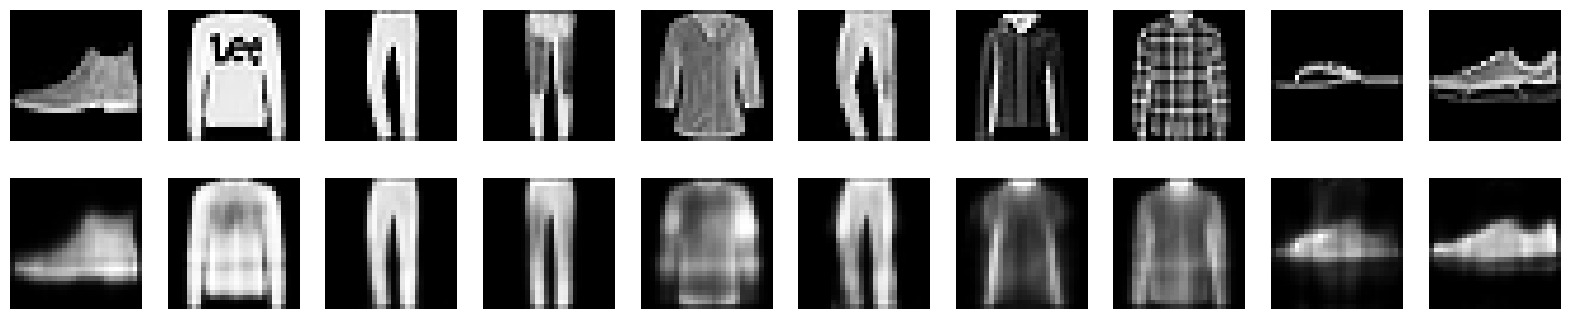

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10 
encoding_dim = 16 
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

undercomplete_autoencoder = tf.keras.Model(input_img, decoded)
undercomplete_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

undercomplete_autoencoder.fit(x_train_flat, x_train_flat,
                             epochs=50,
                             batch_size=256,
                             shuffle=True,
                             validation_data=(x_test_flat, x_test_flat))

decoded_imgs = undercomplete_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

### 5. Contractive Autoencoder:
- Contractive autoencoders introduce an additional penalty during training to make learned representations robust to small changes in input data.
- They minimize both reconstruction error and a regularization term that penalizes sensitivity to input perturbations.
- This results in stable, invariant features useful in noisy or fluctuating environments.


### Implementation

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4154 - val_loss: 0.3442
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3276 - val_loss: 0.3195
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3111 - val_loss: 0.3075
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3014 - val_loss: 0.2998
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2952 - val_loss: 0.2949
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2914 - val_loss: 0.2922
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2891 - val_loss: 0.2903
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2875 - val_loss: 0.2891
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2865 - val_loss: 0.2883
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2857 - val_loss: 0.2876
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2851 - val_loss: 0.2871
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

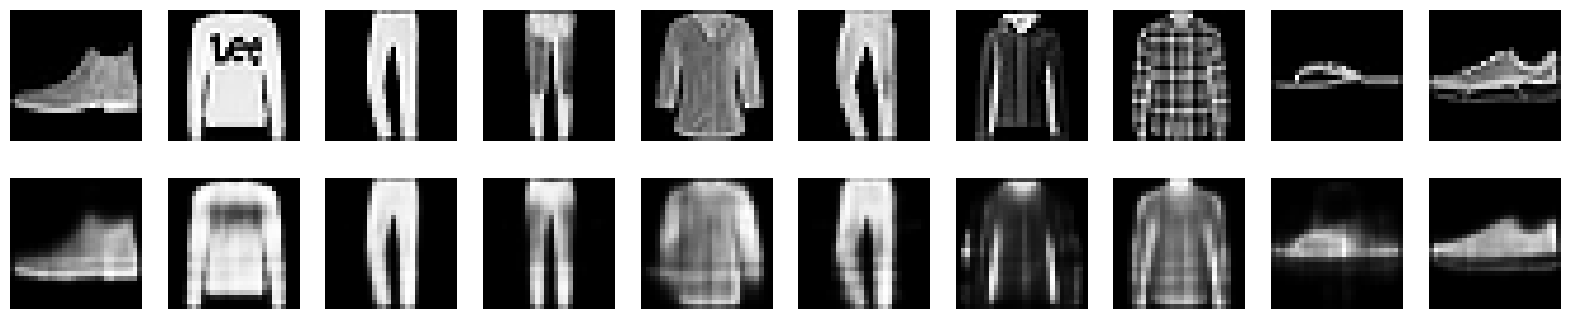

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
encoding_dim = 32
input_img = tf.keras.Input(shape=(784,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_img)
decoded = tf.keras.layers.Dense(784, activation='sigmoid')(encoded)

contractive_autoencoder = tf.keras.Model(input_img, decoded)

def contractive_loss(y_true, y_pred):
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    W = contractive_autoencoder.layers[1].kernel
    dh = tf.gradients(contractive_autoencoded.layers[1].output, input_img)[0]
    contractive = tf.reduce_sum(tf.square(W)) * tf.reduce_sum(tf.square(dh))
    return mse + 1e-4 * contractive

contractive_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
contractive_autoencoder.fit(x_train_flat, x_train_flat, epochs=50, 
                            batch_size=256, shuffle=True, 
                            validation_data=(x_test_flat, x_test_flat))

decoded_imgs = contractive_autoencoder.predict(x_test_flat)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()

### 6. Convolutional Autoencoder:
- Convolutional Autoencoders use convolutional layers to effectively capture spatial and hierarchical features in high-dimensional data such as images.
- These models optimize reconstruction error using loss functions suited for images like mean squared error or binary cross-entropy
- The architecture helps in handling structured inputs by preserving spatial relationships.

### Implementation

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - loss: 0.3594 - val_loss: 0.2984
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.2901 - val_loss: 0.2879
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.2833 - val_loss: 0.2837
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.2798 - val_loss: 0.2807
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.2773 - val_loss: 0.2784
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.2754 - val_loss: 0.2767
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - loss: 0.2737 - val_loss: 0.2750
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 0.2722 - val_loss: 0.2737
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.2711 - val_loss: 0.2727
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.2702 - val_loss: 0.2721
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 0.2694 - val_loss: 0.2713
Epoch 12/50
235/235 ━━━━━━━━━━

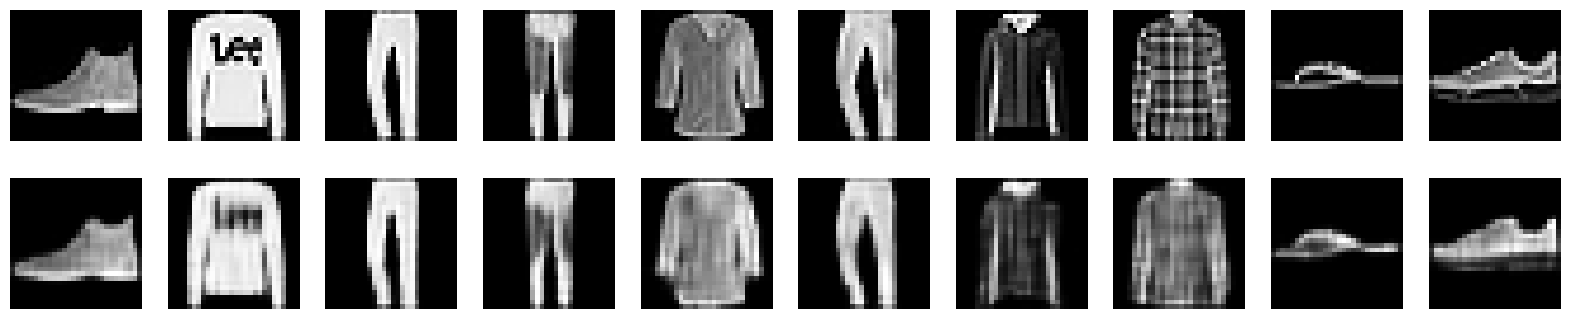

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

x_train_flat = x_train.reshape(len(x_train), 784)
x_test_flat = x_test.reshape(len(x_test), 784)

n = 10
input_img = tf.keras.Input(shape=(28, 28, 1))

x = tf.keras.layers.Conv2D(
    16, (3, 3), activation='relu', padding='same')(input_img)
x = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = tf.keras.layers.MaxPooling2D((2, 2), padding='same')(x)

x = tf.keras.layers.Conv2D(
    8, (3, 3), activation='relu', padding='same')(encoded)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
x = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = tf.keras.layers.UpSampling2D((2, 2))(x)
decoded = tf.keras.layers.Conv2D(
    1, (3, 3), activation='sigmoid', padding='same')(x)

conv_autoencoder = tf.keras.Model(input_img, decoded)
conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

conv_autoencoder.fit(x_train_cnn, x_train_cnn,
                     epochs=50,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test_cnn, x_test_cnn))

decoded_imgs = conv_autoencoder.predict(x_test_cnn)

plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_cnn[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.show()